# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] numpy==1.25.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 104.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization, GlobalAveragePooling2D # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
images = np.load('/content/drive/MyDrive/GL/ComputerVision/Project/images_proj.npy')

labels = pd.read_csv('/content/drive/MyDrive/GL/ComputerVision/Project/Labels_proj.csv')

In [5]:
print(" Shape of the images : ")
print(images.shape) # To print the shape of the images
print(" Shape of the labels :")
print(labels.shape) # To print the shape of the labels
print("The  first 10 labels: ")
print(labels.head(10)) # To print the first 10 labels
print("The  last 10 labels :")
print(labels.tail(10)) # To print the last 10 labels
print("                                          ")
print("Information about the labels :")
print(labels.info()) # To print the information about the labels
print("                                          ")
print("Statistical summary of the labels :")
print(labels.describe()) # To print the statistical summary of the labels

print("                                          ")
print("To check if there are any missing values :")
print(labels.isnull())
print("                                          ")
print("Sum of the number of missing values in the labels :")
print(labels.isnull().sum()) # To print the sum of the number of missing values in the labels
print("                                          ")
print("Unique labels :")
print(labels['Label'].unique()) #To print unique labels

 Shape of the images : 
(631, 200, 200, 3)
 Shape of the labels :
(631, 1)
The  first 10 labels: 
   Label
0      1
1      1
2      1
3      1
4      1
5      1
6      1
7      1
8      1
9      1
The  last 10 labels :
     Label
621      0
622      0
623      0
624      0
625      0
626      0
627      0
628      0
629      0
630      0
                                          
Information about the labels :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Label   631 non-null    int64
dtypes: int64(1)
memory usage: 5.1 KB
None
                                          
Statistical summary of the labels :
            Label
count  631.000000
mean     0.492868
std      0.500346
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      1.000000
                                          
To check if there are any missing values :
     La

Observations :
   
   631 RGB images of shape 200 x 200 X 3, each image having 3 channels.

   631 labels with 1 column named 'Label'.
   
   The values of the first 10 labels ( Value of 1s) and last 10 labels ( Value of 0s) are shown.

   631 non-null values.

   There are no missing values

   Minimum value is 0 and maximum is 1.

   Unique values under the label column is 0 & 1, clearly specifying that it is a binary classification problem.

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

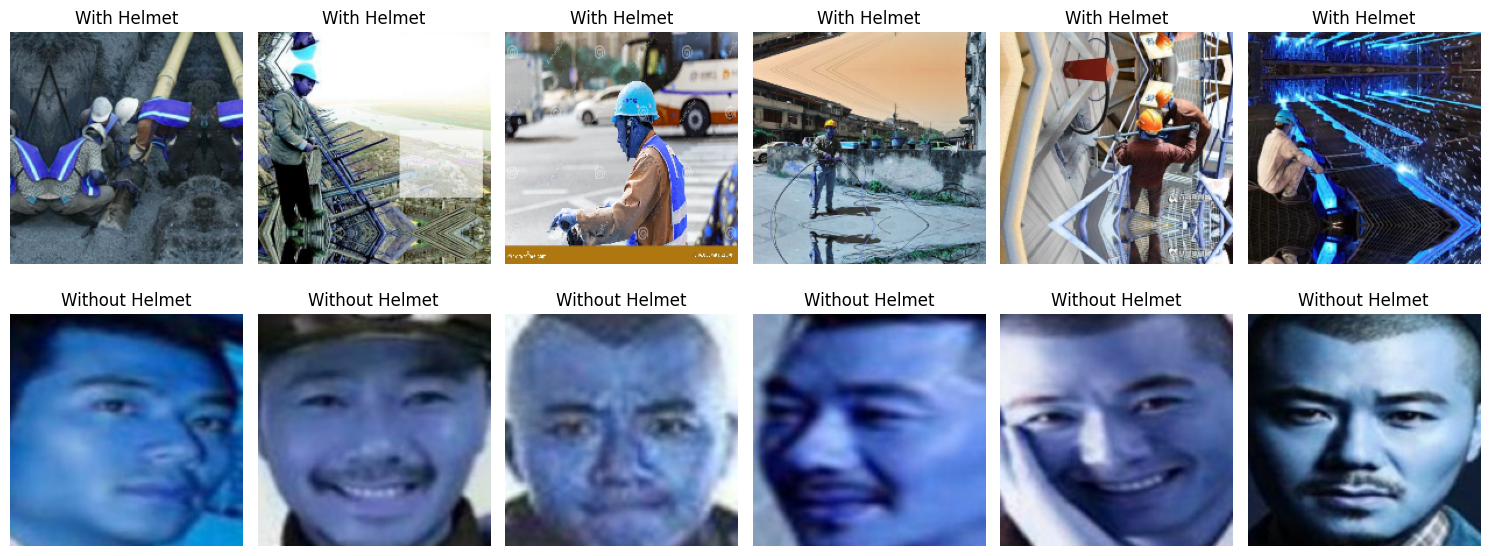

In [6]:
# Displaying randomly selected 6 images from each class

helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]

num_images = 6

# Randomly select 6 images from each class
helmet_selected = np.random.choice(
    helmet_indices,
    size=num_images,
    replace=False
)

no_helmet_selected = np.random.choice(
    no_helmet_indices,
    size=num_images,
    replace=False
)

# Create subplot grid: 2 rows × 6 columns
fig, axes = plt.subplots(2, num_images, figsize=(15, 6))

# First row: With Helmet
for i, idx in enumerate(helmet_selected):
    axes[0, i].imshow(images[idx])
    axes[0, i].set_title("With Helmet")
    axes[0, i].axis('off')

# Second row: Without Helmet
for i, idx in enumerate(no_helmet_selected):
    axes[1, i].imshow(images[idx])
    axes[1, i].set_title("Without Helmet")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Observations:


 6 images each of "With Helmet" and "Without Helmet" is shown in the plot of images above and has correctly identified the images with the labels 1 and 0 respectively!  

## Checking for class imbalance


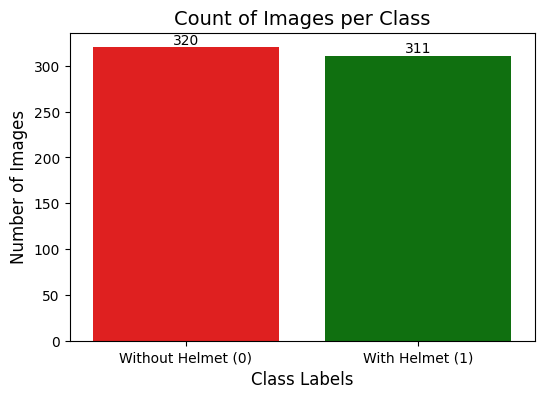

In [7]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

Observations 🇰

There are 320 images without helmet and 311 images with Helmet.

# **Data Preprocessing**

## Converting images to grayscale

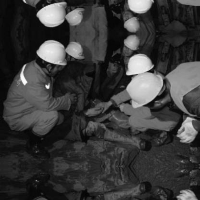

In [8]:
images_gray = []
for i in range(len(images)):
    img_gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    images_gray.append(img_gray)

# Display a sample grayscale image
n = 4
cv2_imshow(images_gray[n])

Observation :

A gray scale image is seen in the above sample after conversion from RGB image!

### Splitting the dataset



- As we have less images in our dataset, we will only use 15% of our data for testing, 15% of our data for validation and 70% of our data for training.
- We are using the `train_test_split()` function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.3, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [10]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(441, 200, 200, 3) (441, 1)
(95, 200, 200, 3) (95, 1)
(95, 200, 200, 3) (95, 1)


Observations -

Train-Validation-Test sets have 70-15-15 split ratio.

Train set - (X_train) has 441  RGB images of shape 200 x 200 X 3, each image having 3 channels.

Validation set - (X_val) has 95 RGB images of shape 200 x 200 X 3, each image having 3 channels.

Test set - (X_test) has 95 RGB images of shape 200 x 200 X 3, each image having 3 channels.





### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [11]:
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

print(X_train_normalized.shape,y_train.shape)
print(X_val_normalized.shape,y_val.shape)
print(X_test_normalized.shape,y_test.shape)
print("Max_value for X_train after Normalize :",X_train_normalized.max())
print("Min_value for X_train after Normalize :",X_train_normalized.min())
print("Max_value for X_val after Normalize :",X_val_normalized.max())
print("Min_value for X_val after Normalize :",X_val_normalized.min())
print("Max_value for X_test after Normalize :",X_test_normalized.max())
print("Min_value for X_test after Normalize :",X_test_normalized.min())

(441, 200, 200, 3) (441, 1)
(95, 200, 200, 3) (95, 1)
(95, 200, 200, 3) (95, 1)
Max_value for X_train after Normalize : 1.0
Min_value for X_train after Normalize : 0.0
Max_value for X_val after Normalize : 1.0
Min_value for X_val after Normalize : 0.0
Max_value for X_test after Normalize : 1.0
Min_value for X_test after Normalize : 0.0


Observation -

 All the sets are normalized as we can check through the minimum values being 0 and maximum values being 1 for train,validation and test set.

# **Model Building**

##Model Evaluation Criterion

As we see from the Data overview and EDA images that this is clearly a binary classification problem distinguishing between images with person/persons wearing a helmet or without helmet.

As we need accurate prediction of the images , we choose the metric of "Accuracy".

## Utility Functions

Defining a function to compute different metrics( Accuracy, Recall, Precision, F1 Score) to check performance of a classification model.

In [12]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

Defining a function to plot confusion matrix.

In [13]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

Let's build a **CNN Model**.<br>

The model has 2 main parts:
1. **The Feature Extraction layers** which are comprised of convolutional and pooling layers.
2. **The Fully Connected classification layers for prediction.**<br><br>





In [14]:
model_1 = Sequential()

# Convolutional layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200, 200, 3))) # Input shape based on previous X_train, X_val, X_test shapes
model_1.add(MaxPooling2D((2, 2), padding='same'))
model_1.add(Conv2D(64, (3, 3), activation='relu', padding="same"))
model_1.add(MaxPooling2D((2, 2), padding='same'))
model_1.add(Conv2D(128, (3, 3), activation='relu', padding="same"))

#The Globalaverage Pooling is chosen over the flatten to convert into a 1D layer. This is preferred over the flatten layer as the number of trainable parameters will be less compared to the Flatten layer before feeding it to the fully connected layer.
model_1.add(GlobalAveragePooling2D())

# Flatten and Dense layers - Not using the flatten layer below as it is redundant.
#model_1.add(Flatten())

model_1.add(Dense(32, activation='relu')) # Adjusted dense layer neurons
model_1.add(Dropout(0.5)) # Dropout layer for regularization
model_1.add(Dense(1, activation='sigmoid'))  # 1 neuron for binary classification, sigmoid activation

# Compile with Adam Optimizer
opt = Adam(learning_rate=0.001)
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy"])

# Summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,409 (380.50 KB)

 Trainable params: 97,409 (380.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=10,
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=128,
            verbose=2
)

Epoch 1/10
4/4 - 25s - 6s/step - accuracy: 0.5374 - loss: 0.6892 - val_accuracy: 0.8316 - val_loss: 0.6648
Epoch 2/10
4/4 - 1s - 133ms/step - accuracy: 0.6961 - loss: 0.6480 - val_accuracy: 0.8421 - val_loss: 0.6062
Epoch 3/10
4/4 - 1s - 134ms/step - accuracy: 0.7846 - loss: 0.5874 - val_accuracy: 0.8737 - val_loss: 0.5274
Epoch 4/10
4/4 - 1s - 133ms/step - accuracy: 0.9025 - loss: 0.4733 - val_accuracy: 0.9158 - val_loss: 0.3722
Epoch 5/10
4/4 - 1s - 134ms/step - accuracy: 0.9116 - loss: 0.3425 - val_accuracy: 0.9789 - val_loss: 0.2268
Epoch 6/10
4/4 - 1s - 134ms/step - accuracy: 0.9456 - loss: 0.2226 - val_accuracy: 0.9789 - val_loss: 0.1351
Epoch 7/10
4/4 - 1s - 134ms/step - accuracy: 0.9683 - loss: 0.1571 - val_accuracy: 0.9895 - val_loss: 0.0885
Epoch 8/10
4/4 - 1s - 134ms/step - accuracy: 0.9773 - loss: 0.1125 - val_accuracy: 0.9895 - val_loss: 0.0662
Epoch 9/10
4/4 - 1s - 134ms/step - accuracy: 0.9751 - loss: 0.1008 - val_accuracy: 0.9789 - val_loss: 0.0652
Epoch 10/10
4/4 - 1s 

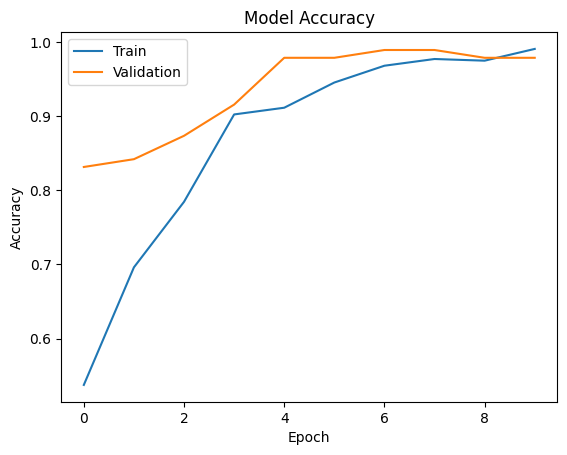

In [16]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Observations :

Training Accuracy increased well from  the beginning ,around 54 %  to close to 99 %  in the 10th epoch. Steady increase in the learning.

Validation Accuracy started at 83 % accuracy at the first epoch and   reached 98% accuracy by the 10th epoch.

Good convergence between the 2 sets by the final 10th epoch!

The model learning is very good!



In [17]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step
Train performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.986395  0.986395   0.986433  0.986393


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


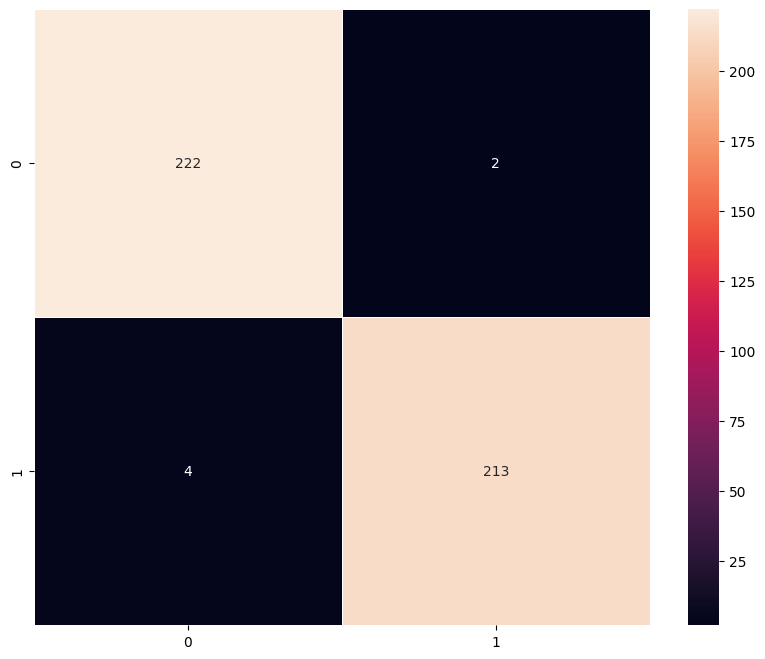

In [18]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [19]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
Validation performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.978947  0.978947   0.979807  0.978943


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


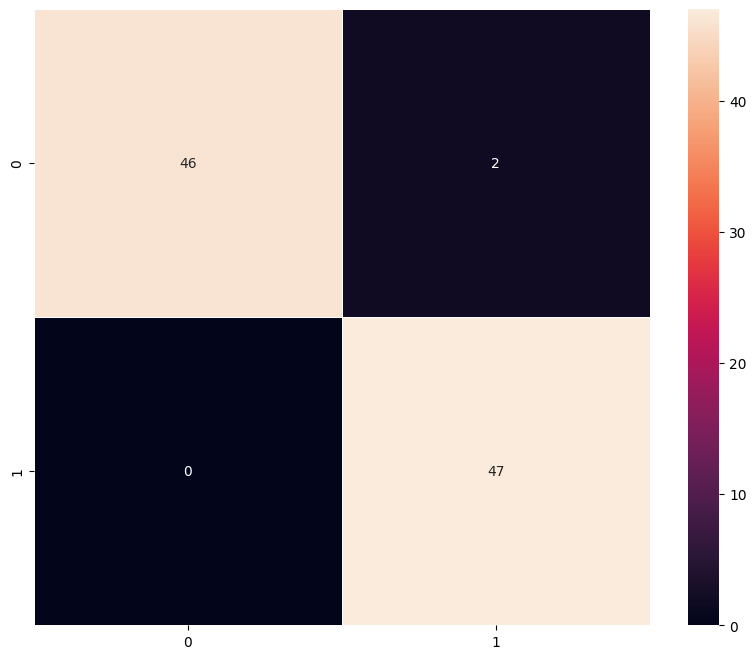

In [20]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

Observation -

 From the confusion matrix , training data has missed very few cases in the both cases of without helmet ( 2) and  with helmet (4). The Validation data has definitely performed better over all!

### Vizualizing the predictions

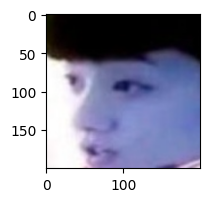

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
For Index 1 :- 
Predicted Label: 0
True Label: Label    0
Name: 341, dtype: int64


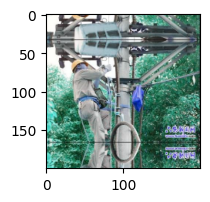

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
For Index 23 :- 
Predicted Label: 1
True Label: Label    1
Name: 190, dtype: int64


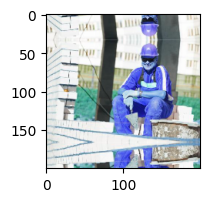

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
For Index 45 :- 
Predicted Label: 1
True Label: Label    1
Name: 50, dtype: int64


In [21]:

# For index 1
plt.figure(figsize=(2,2))
plt.imshow(X_val[1])
plt.show()
prediction = model_1.predict(X_val_normalized[1].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 1 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[1]
print('True Label:', true_label)


# For index 23
plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
prediction = model_1.predict(X_val_normalized[23].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 23 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[23]
print('True Label:', true_label)

# For index 45
plt.figure(figsize=(2,2))
plt.imshow(X_val[45])
plt.show()
prediction = model_1.predict(X_val_normalized[45].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 45 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[45]
print('True Label:', true_label)

Observations:

The model has predicted all the 3 images correctly from the above visualization of the prediction.


## Model 2: (VGG-16 (Base))

- We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.


In [25]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [28]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

#The Globalaverage Pooling is chosen over the flatten to convert into a 1D layer. This is preferred over the flatten layer as the number of trainable parameters will be less compared to the Flatten layer before feeding it to the fully connected layer.
model_2.add(GlobalAveragePooling2D())

# Flatten and Dense layers - Not using the flatten layer below as it is redundant.
#model_1.add(Flatten())

# Adding a dense output layer for binary classification
model_2.add(Dense(1, activation='sigmoid'))

In [29]:
opt=Adam(learning_rate=0.0001)
# Compile model
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [30]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
train_datagen = ImageDataGenerator()

In [32]:
# Epochs
epochs = 10
# Batch size
batch_size = 128

history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=True),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 12s/step - accuracy: 0.4760 - loss: 0.7464 - val_accuracy: 0.5053 - val_loss: 0.7228
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5703 - loss: 0.7257 - val_accuracy: 0.5053 - val_loss: 0.7218
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.5335 - loss: 0.7261 - val_accuracy: 0.5053 - val_loss: 0.7190
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4453 - loss: 0.7599 - val_accuracy: 0.5158 - val_loss: 0.7180
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.4760 - loss: 0.7401 - val_accuracy: 0.5158 - val_loss: 0.7150
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5859 - loss: 0.7134 - val_accuracy: 0.5158 - val_loss: 0.7141
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.5208 - loss: 0.7252 - val_accuracy: 0.5368 - val_loss: 0.7112
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4766 - loss: 0.7353 - val_accuracy: 0.5368 - val_loss: 0.7

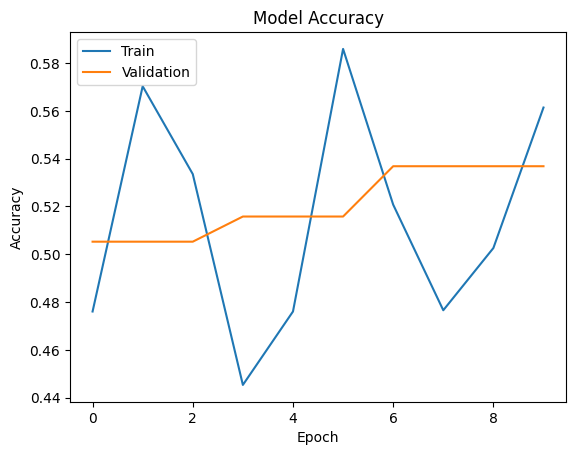

In [33]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Observations -

 From the plot above we can see the model is very much underfitting and has reached less than 60 % maximum accuracy in both the train and validation sets. The model didn't learn well and is underfitting.

In [34]:
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 431ms/step
Train performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.512472  0.512472    0.53274  0.381025


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


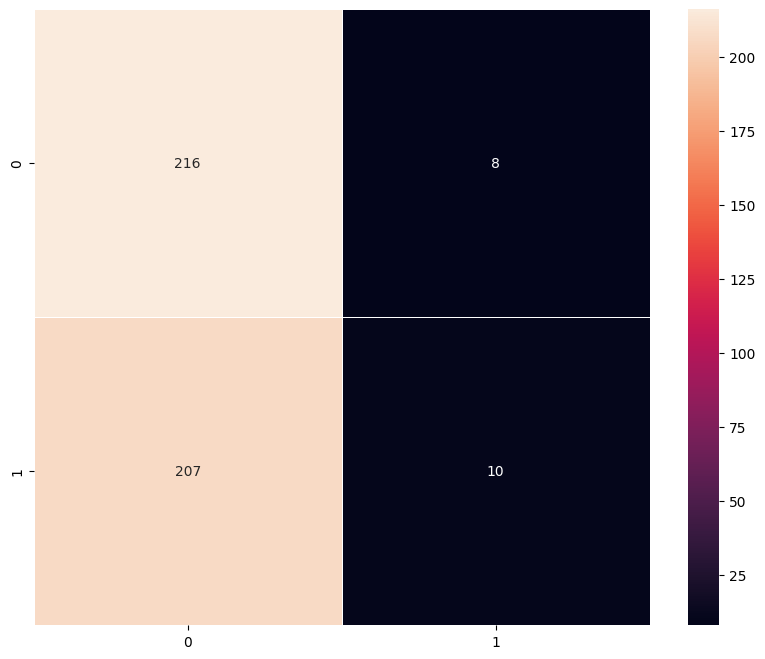

In [35]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [36]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step
Validation performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.536842  0.536842   0.594206  0.445371


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


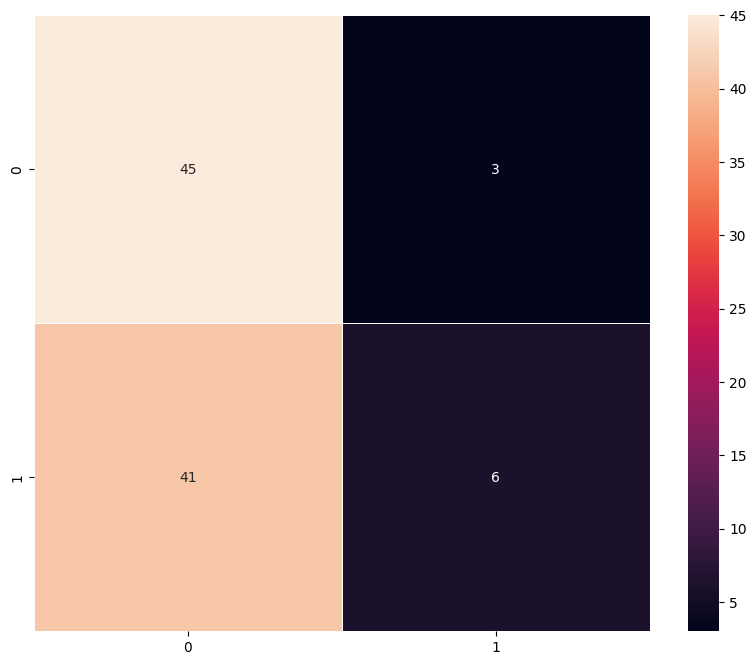

In [37]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

Observations -

The confusion matrix clearly indicates that the model has predicted mostly True negative cases(216,45) correctly but has missed True postive cases (207,41)  in the both the train and validation sets! This is a classic example of class imbalance in prediction and is underfitting.

### Visualizing the prediction:

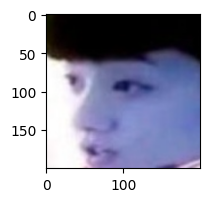

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
For Index 1 :- 
Predicted Label: 0
True Label: Label    0
Name: 341, dtype: int64


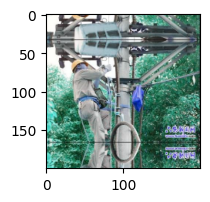

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
For Index 23 :- 
Predicted Label: 0
True Label: Label    1
Name: 190, dtype: int64


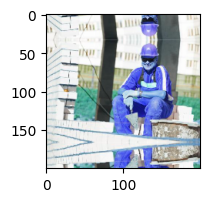

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
For Index 45 :- 
Predicted Label: 0
True Label: Label    1
Name: 50, dtype: int64


In [38]:

# For index 1
plt.figure(figsize=(2,2))
plt.imshow(X_val[1])
plt.show()
prediction = model_2.predict(X_val_normalized[1].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 1 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[1]
print('True Label:', true_label)

#For index 23

plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
prediction = model_2.predict(X_val_normalized[23].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5
print("For Index 23 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[23]
print('True Label:', true_label)

#For index 45

plt.figure(figsize=(2,2))
plt.imshow(X_val[45])
plt.show()
prediction = model_2.predict(X_val_normalized[45].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 45 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[45] #Complete the code to define the index
print('True Label:', true_label)

For indices 23 & 45 images, it has been predicted incorrectly in the above visualization. Predicted label is 0 i.e without helmet and the actual image from above is a person with  helmet. ( label - 1)

We will add feed forward neural network layers and dense layers to the VGG16 architecture to see if we can improve the model learning.

## Model 3: (VGG-16 (Base + FFNN))

- We will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will convert to 1D layer  and a Feed Forward Neural Network.

Adding Dense layers with 256 neurons --> Dropout rate of 0.5 , followed by dense layers of 64 neurons --> Dropout rate of 0.3



In [40]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

#The Globalaverage Pooling is chosen over the flatten to convert into a 1D layer.
#This is preferred over the flatten layer as the number of trainable parameters will be less compared to the Flatten layer before feeding it to the fully connected layer.
model_3.add(GlobalAveragePooling2D())

# Flatten and Dense layers - Not using the flatten layer below as it is redundant.
#model_3.add(Flatten())


#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.5))
model_3.add(Dense(64,activation='relu'))
model_3.add(Dropout(rate=0.3))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [41]:
opt = Adam(learning_rate=0.0001)

In [42]:
# Compile model
model_3.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [43]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,862,529 (56.70 MB)

 Trainable params: 147,841 (577.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [44]:
history_3 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128,
                                       seed=42,
                                       shuffle=True),
                    epochs=10,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.5016 - loss: 0.8454 - val_accuracy: 0.4947 - val_loss: 0.6925
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5625 - loss: 0.7769 - val_accuracy: 0.4947 - val_loss: 0.6785
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.5367 - loss: 0.7276 - val_accuracy: 0.5053 - val_loss: 0.6438
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5469 - loss: 0.7456 - val_accuracy: 0.5789 - val_loss: 0.6342
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.5469 - loss: 0.7200 - val_accuracy: 0.8737 - val_loss: 0.6104
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5965 - loss: 0.7237 - val_accuracy: 0.9158 - val_loss: 0.6036
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.6070 - loss: 0.6600 - val_accuracy: 0.9368 - val_loss: 0.5857
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6016 - loss: 0.6445 - val_accuracy: 0.9474 - val_loss: 0.58

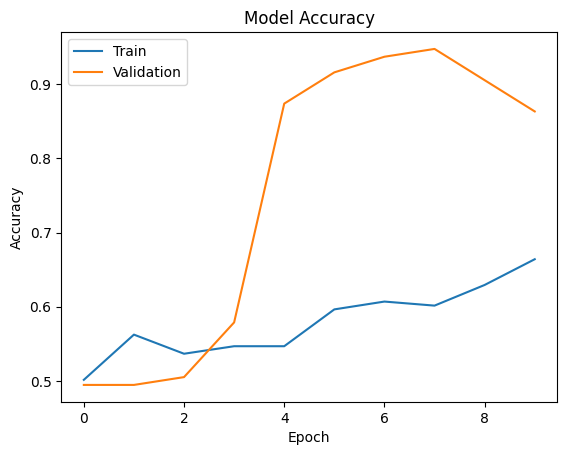

In [45]:
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Observations -

 From the plot we observe that Validation set has performed better than training set. The maximum accuracy this model reached is 86 % in the validation set and the training set did not improve beyond 66 % . Increasing the epochs for this same model will help the training set to learn better and reach higher accuracy!

 Even though this model learnt better from the previous base VGG16 model and is generalizing better we will see if adding data augmentation will improve the model performance!

In [46]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step
Train performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.879819  0.879819   0.902814  0.877816


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


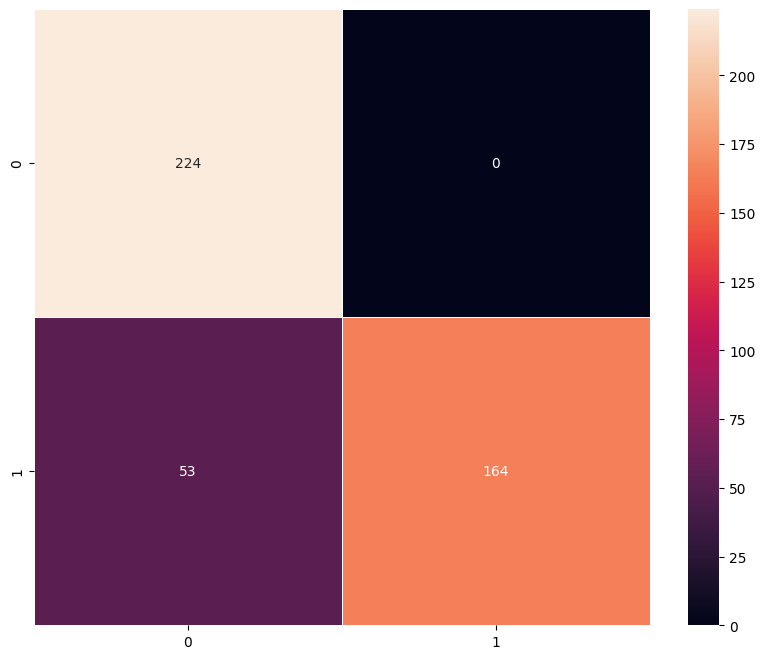

In [47]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [48]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 478ms/step
Validation performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.863158  0.863158   0.892321  0.860337


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


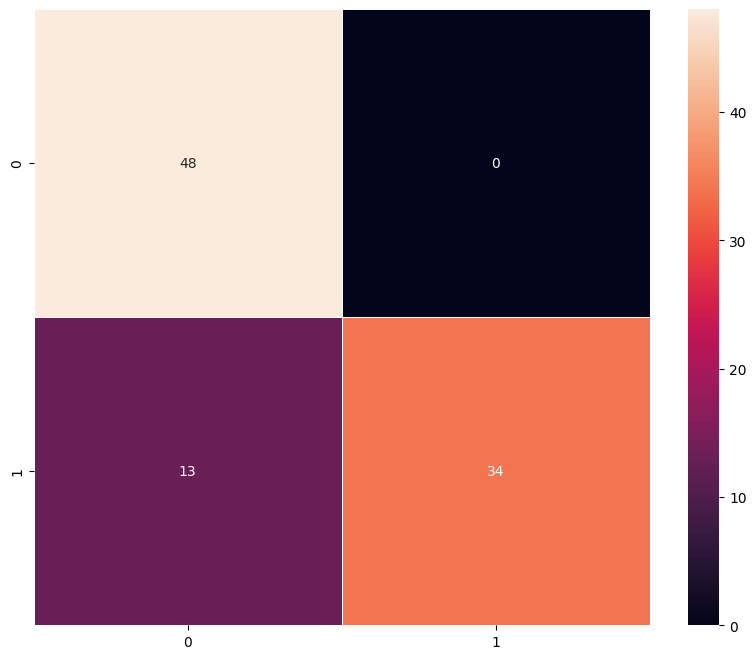

In [49]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

Observation -

 From the confusion matrix we observe -

 * Training data has  correctly identified 164 True positives  (label 1 -  with helmet images) and missed 53 cases. Correctly identified 224 True negatives (label 0 - without helmet) and missed none.

* Validation data has  correctly identified 34 True positives  (label 1 -  with helmet images) and missed 13 cases. Correctly identified 48 True negatives (label 0 - without helmet) and missed none.

This model is still predicting all the True negatives well but has missed predicting label 1 ( True positives ) , images with helmet. Will verify if adding data augmentation layer will improve the generaliztion of the model better by catching more true positives in further analysis!

#### Visualizing the predictions

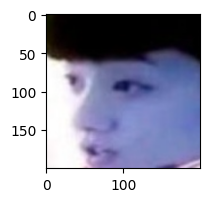

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
For Index 1 :- 
Predicted Label: 0
True Label: Label    0
Name: 341, dtype: int64


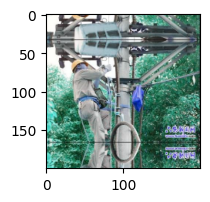

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
For Index 23 :- 
Predicted Label: 1
True Label: Label    1
Name: 190, dtype: int64


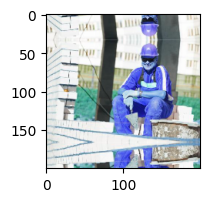

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
For Index 45 :- 
Predicted Label: 1
True Label: Label    1
Name: 50, dtype: int64


In [50]:
# For index 1
plt.figure(figsize=(2,2))
plt.imshow(X_val[1])
plt.show()
prediction = model_3.predict(X_val_normalized[1].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 1 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[1]
print('True Label:', true_label)

#For index 23
plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
prediction = model_3.predict(X_val_normalized[23].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 23 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[23]
print('True Label:', true_label)

#For index 45
plt.figure(figsize=(2,2))
plt.imshow(X_val[45])
plt.show()
prediction = model_3.predict(X_val_normalized[45].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 45 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[45]
print('True Label:', true_label)

Observations:

The model has predicted all the 3 images correctly from the above visualization of the prediction of the respective indices.


With the transfer learning architecture VGG-16 and FFNN we see a little progress in the model to learn the data , we now will add the data augmentation to the transfer learning to see if the model will perform better and show any improvement!

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

For classification, we will convert to 1D layer  and a Feed Forward Neural Network.

Adding Dense layers with 256 neurons --> Dropout rate of 0.5 , followed by dense layers of 32 neurons in this Neural network prior to data augmentation.


- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

Fine tuning the data augmentation layer with these paramters specified below  -

            - rotation_range=10
            - fill_mode='nearest'
            - width_shift_range=0.1                  
            - height_shift_range=0.1
            - shear_range=0.2
            - horizontal_flip=True
            - vertical_flip=True
            - zoom_range=0.2
                              

                              

In [51]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)


#The Globalaverage Pooling is chosen over the flatten to convert into a 1D layer. This is preferred over the flatten layer as the number of trainable parameters will be less compared to the Flatten layer before feeding it to the fully connected layer.
model_4.add(GlobalAveragePooling2D())

# Flatten and Dense layers - Not using the flatten layer below as it is redundant.
#model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu'))
model_4.add(Dropout(rate=0.5))
model_4.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [52]:
opt=Adam(learning_rate=0.0001)
# Compile model
model_4.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [53]:
# Generating the summary of the model
model_4.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,854,273 (56.66 MB)

 Trainable params: 139,585 (545.25 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [54]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=10,
                              fill_mode='nearest',
                              width_shift_range=0.1,
                              height_shift_range=0.1,
                              shear_range=0.2,
                              horizontal_flip=True,
                              vertical_flip=True,
                              zoom_range=0.2
                              )

In [55]:
history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=128,
                                       seed=42,
                                       shuffle=True),
                    epochs=10,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.5527 - loss: 0.7125 - val_accuracy: 0.8316 - val_loss: 0.6364
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5859 - loss: 0.6897 - val_accuracy: 0.8421 - val_loss: 0.6297
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 843ms/step - accuracy: 0.5527 - loss: 0.7054 - val_accuracy: 0.8737 - val_loss: 0.6105
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.5859 - loss: 0.6797 - val_accuracy: 0.8737 - val_loss: 0.6040
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 744ms/step - accuracy: 0.6102 - loss: 0.6791 - val_accuracy: 0.8947 - val_loss: 0.5853
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.6016 - loss: 0.6466 - val_accuracy: 0.8947 - val_loss: 0.5793
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 802ms/step - accuracy: 0.6294 - loss: 0.6370 - val_accuracy: 0.9474 - val_loss: 0.5612
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7109 - loss: 0.5977 - val_accuracy: 0.9474 - val_loss: 0.555

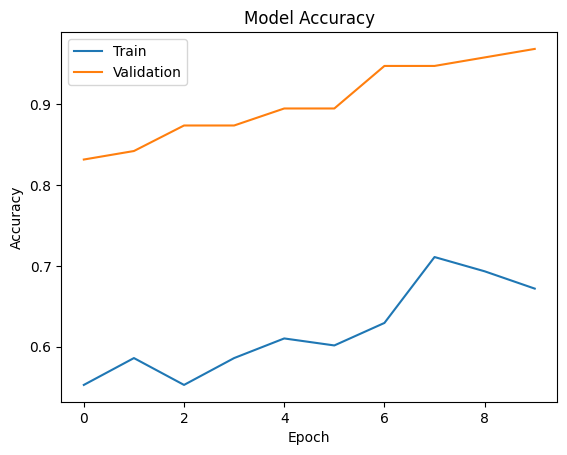

In [56]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Observations : -

The training data accuracy continues to rise to about 71% at epoch 8 from 55% in Epoch 1


However, the Validation data started off very well at 83% accuracy at epoch 1 and reaching 97% accuracy at th 10th epoch.

Validation performance stays much higher consistently compared to the training data from the graph. The gap is visible between the 2 sets and it has generalized well between the 2 sets.

In [57]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step
Train performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.954649  0.954649   0.958366  0.954522


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


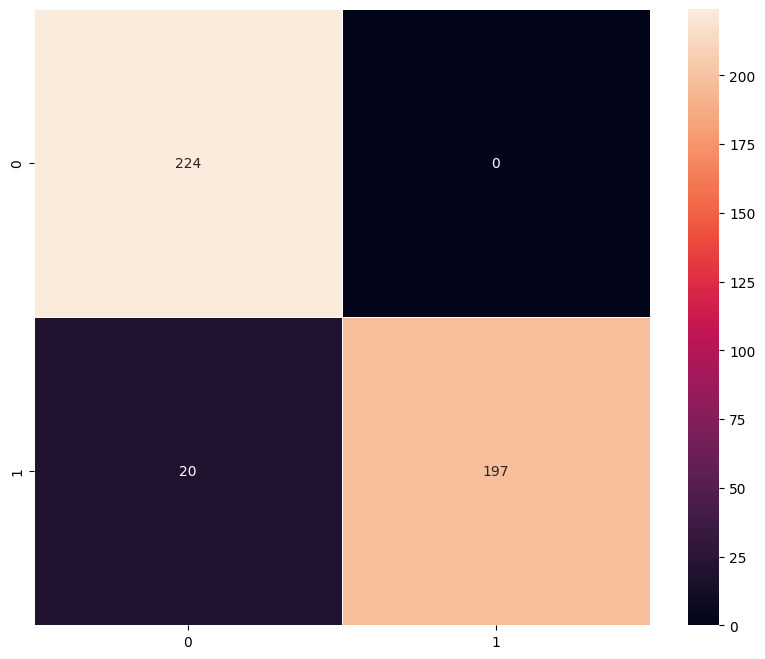

In [58]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [59]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step
Validation performance metrics
   accuracy    Recall  Precision  F1 Score
0  0.968421  0.968421   0.970279  0.968379


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


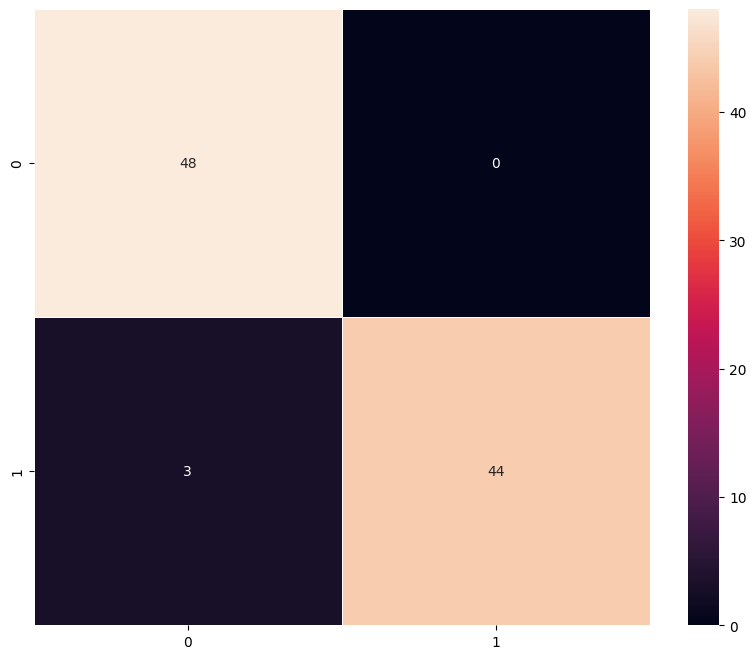

In [60]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

Observations -

  The confusion matrix shows a drastic improvement from the previous model of predicting very good number of True positives - 197 & 44 cases respectively in the train and validation sets and has missed less number of True positives. This model improved generalization.

#### Visualizing the predictions

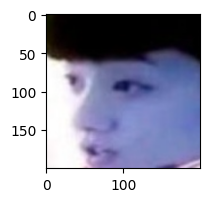

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
For Index 1 :- 
Predicted Label: 0
True Label: Label    0
Name: 341, dtype: int64


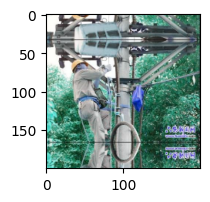

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
For Index 23 :- 
Predicted Label: 1
True Label: Label    1
Name: 190, dtype: int64


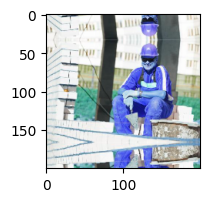

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
For Index 45 :- 
Predicted Label: 1
True Label: Label    1
Name: 50, dtype: int64


In [61]:

#For index 1
plt.figure(figsize=(2,2))
plt.imshow(X_val[1])
plt.show()
prediction = model_4.predict(X_val_normalized[1].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 1 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[1]
print('True Label:', true_label)

#For index 23
plt.figure(figsize=(2,2))
plt.imshow(X_val[23])
plt.show()
prediction = model_4.predict(X_val_normalized[23].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label

print("For Index 23 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[23]
print('True Label:', true_label)

#For index 45
plt.figure(figsize=(2,2))
plt.imshow(X_val[45])
plt.show()
prediction = model_4.predict(X_val_normalized[45].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print("For Index 45 :- ")
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[45]
print('True Label:', true_label)

Observations:

The model has predicted all the 3 images correctly from the above visualization of the prediction.


# **Model Performance Comparison and Final Model Selection**

In [62]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [63]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [64]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
accuracy,0.986395,0.512472,0.879819,0.954649
Recall,0.986395,0.512472,0.879819,0.954649
Precision,0.986433,0.532740,0.902814,0.958366
F1 Score,0.986393,0.381025,0.877816,0.954522


In [65]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
accuracy,0.978947,0.536842,0.863158,0.968421
Recall,0.978947,0.536842,0.863158,0.968421
Precision,0.979807,0.594206,0.892321,0.970279
F1 Score,0.978943,0.445371,0.860337,0.968379


In [66]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
accuracy,0.007447,-0.024370,0.016661,-0.013773
Recall,0.007447,-0.024370,0.016661,-0.013773
Precision,0.006626,-0.061466,0.010493,-0.011913
F1 Score,0.007451,-0.064345,0.017479,-0.013857


From the above performance comparison of all models, both model 1 and  model 4 has good metric scores. Testing these models with the test performance will help us better understand how these models work on the unseen data.

## Test Performance

In [74]:
model_test_perf = model_performance_classification(model_1, X_test_normalized,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [75]:
model_test_perf

,accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


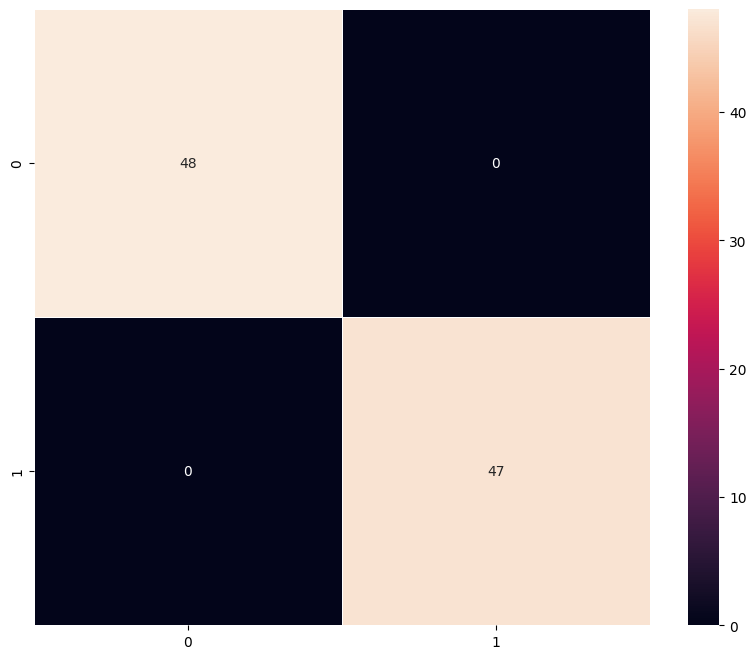

In [76]:
plot_confusion_matrix(model_1, X_test_normalized,y_test)

In [77]:
model_test_perf = model_performance_classification(model_4, X_test_normalized,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [78]:
model_test_perf

,accuracy,Recall,Precision,F1 Score
0,0.957895,0.957895,0.961134,0.957801


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


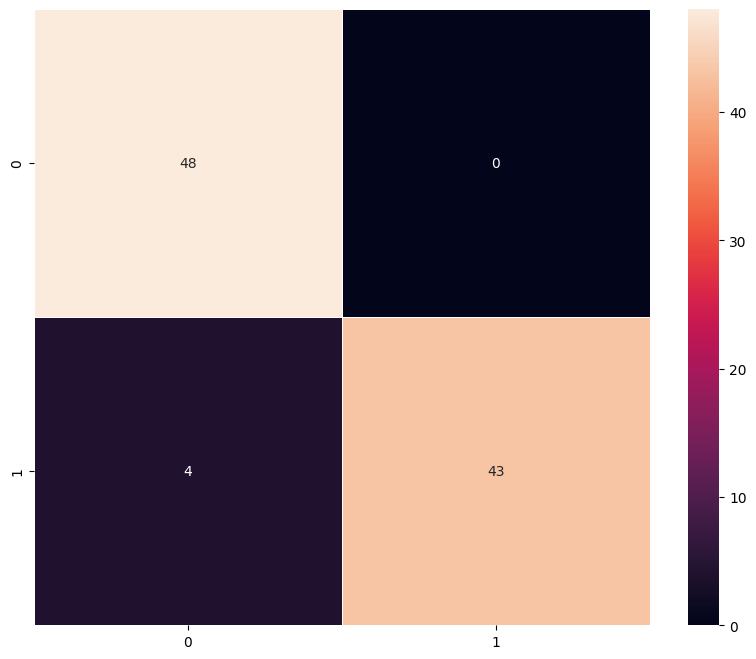

In [79]:
plot_confusion_matrix(model_4, X_test_normalized,y_test)

Observations -

The test performance  confirms that model 4 is the best model to chose while comparing with model 1. Model 1 is overfitting ,model 4 is generalizing well and has reduced overfitting of model 1 ! Model 4 is generalizing well with the unseen data. Hence model 4  is chosen as the final model.

# **Actionable Insights & Recommendations**

Four models were evaluated:

 Model 1 : Simple convolution Neural Network ,

 Model 2 : VGG16 base model,

 Model 3 : VGG16 model with a feed-forward neural network (FFNN)

 Model 4 : VGG16+FFNN model with data augmentation.


   

   -  Model 1- Simple Convolution Neural Network achieved  high validation accuracy (97.89%) but the VGG16+FFNN+Data Augmentation model generalized well and performed good with unseen data without overfitting unlike in the model 1. Hence we choose Model 4 as the best model out of all the models .

  - On the unseen test set , Model 4  metric scores were good and appropriate for good generalization performance - (95.78% accuracy , recall of 95.78% ,96.11% Precission and 95.78 % - F1 Score)  Therefore, the VGG16+FFNN+Data Augmentation model was selected as the final model due to its superior generalization performance out of the 4 models!
  

  - Data Augmentation possibly could have captured all sorts of images while fine tuning the parameters. For example, vertical flip and horizontal flip set to True  could have aided in better capturing the images with helmet and non-helmet correctly in both the directions and shear range could have helped all angles compared to the base model and Feedforward model in the VGG16 architecture.

  - Adding the base VGG16 architecture to the CNN did not help much in learning and it was underfitting with maximum accuracy reaching only 50 % maximum accuracy. However in Model 3 adding the feed forward neural network with adding Dense layers and drop outs , there was a significant improvement in learning. Adding data augmentation to the Feed forward neural network did enhance the performance at a significant rate and helped in reaching the best performance!  

  
  - Calibrating images through various transfer learning architectures can help in assessing the CNN model better to capture all kinds of data images!

  - For not missing various scenarios of workers in different conditions , make sure the dataset is vast enough to collect all sorts of images under diverse conditions of dust, weather and even in case of emergency situations such as fires or malfunctioning of any industrical plant with smog etc. This will help and enhance the efficiency of capturing images by the model for exceptional cases as well!  








<font size=5 color='blue'>Power Ahead!</font>
___